# NumPy e Pandas
## Fundamentos de Analise de Dados com Python

---

**Objetivos de Aprendizagem:**
- Compreender a estrutura e vantagens do NumPy
- Criar e manipular arrays multidimensionais
- Compreender as estruturas Series e DataFrame do Pandas
- Carregar, filtrar, transformar e analisar dados tabulares
- Aplicar operacoes de agrupamento e agregacao

---

# PARTE 1 — NumPy
## Numerical Python

O **NumPy** e a base da computacao cientifica em Python.  
Ele fornece um objeto de array multidimensional altamente eficiente e funcoes matematicas otimizadas.

**Por que usar NumPy?**
- Arrays sao muito mais rapidos que listas Python
- Operacoes vetorizadas (sem loops)
- Suporte a algebra linear, estatistica, numeros aleatorios
- Base do Pandas, Matplotlib, Scikit-learn etc.

---
## 1.1 Importando o NumPy

In [32]:
import numpy as np

print('NumPy importado com sucesso!')
print(f'Versao: {np.__version__}')

NumPy importado com sucesso!
Versao: 2.2.6


---
## 1.2 Array vs Lista Python

A diferenca fundamental: **arrays NumPy sao tipados e contiguos na memoria**.

In [33]:
# Lista Python
lista = [1, 2, 3, 4, 5]

# Array NumPy
array = np.array([1, 2, 3, 4, 5])

print('Lista Python:', lista)
print('Array NumPy: ', array)
print()
print('Tipo da lista:', type(lista))
print('Tipo do array:', type(array))
print()

# Diferenca em operacoes matematicas
print('lista * 2:', lista * 2)       # repete a lista!
print('array * 2:', array * 2)      # multiplica cada elemento

Lista Python: [1, 2, 3, 4, 5]
Array NumPy:  [1 2 3 4 5]

Tipo da lista: <class 'list'>
Tipo do array: <class 'numpy.ndarray'>

lista * 2: [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
array * 2: [ 2  4  6  8 10]


In [34]:
import time

tamanho = 1_000_000

# Com lista Python
lista = list(range(tamanho))
inicio = time.time()
resultado_lista = [x * 2 for x in lista]
tempo_lista = time.time() - inicio

# Com array NumPy
array = np.arange(tamanho)
inicio = time.time()
resultado_array = array * 2
tempo_numpy = time.time() - inicio

print(f'Lista Python: {tempo_lista:.4f} segundos')
print(f'Array NumPy:  {tempo_numpy:.4f} segundos')
print(f'NumPy foi {tempo_lista/tempo_numpy:.1f}x mais rapido!')

Lista Python: 0.0359 segundos
Array NumPy:  0.0010 segundos
NumPy foi 35.9x mais rapido!


---
## 1.3 Criando Arrays

In [35]:
# A partir de uma lista
a1 = np.array([10, 20, 30, 40, 50])
print('A partir de lista:', a1)

# Array de zeros                        # REPETE O NÚMEOR EM UMA LISTA 
zeros = np.zeros(5)
print('Zeros:', zeros)

# Array de uns                          # REPETE O NÚMERO "UM" EM UMA LISTA 
uns = np.ones(5)
print('Uns:  ', uns)

# Valor constante
constante = np.full(5, 7)
print('Constante:', constante)

# Sequencia (similar ao range)            #VAI PULANDO A LISTA DE 2 EM 2
sequencia = np.arange(0, 20, 2)     # de 0 ate 20, passo 2
print('Arange:   ', sequencia)

# Valores igualmente espacados
espacado = np.linspace(0, 1, 6)     # 6 valores entre 0 e 1
print('Linspace: ', espacado)

# Array identidade                         # GERA UMA MATRIZ DE IDENTIDADE
identidade = np.eye(3) 
print('Identidade 3x3:')
print(identidade)

A partir de lista: [10 20 30 40 50]
Zeros: [0. 0. 0. 0. 0.]
Uns:   [1. 1. 1. 1. 1.]
Constante: [7 7 7 7 7]
Arange:    [ 0  2  4  6  8 10 12 14 16 18]
Linspace:  [0.  0.2 0.4 0.6 0.8 1. ]
Identidade 3x3:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [36]:
# Numeros aleatorios
np.random.seed(6156)   # para reproducibilidade

# Floats uniformes entre 0 e 1
aleatorio = np.random.rand(5)
print('Uniforme [0,1):   ', np.round(aleatorio, 2))

# Distribuicao normal (media=0, desvio=1)
normal = np.random.randn(5)
print('Normal (0,1):     ', np.round(normal, 2))

# Inteiros aleatorios
inteiros = np.random.randint(1, 101, size=8)   # entre 1 e 100
print('Inteiros [1,100]: ', inteiros)

Uniforme [0,1):    [0.55 0.15 0.26 0.41 0.14]
Normal (0,1):      [-0.35  0.17  1.02  0.61  0.99]
Inteiros [1,100]:  [68 99 86 39 25 85 60 33]


---
## 1.4 Atributos dos Arrays

In [37]:
# Array 2D (matriz)
matriz = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

print('Array:')
print(matriz)
print()
print(f'Numero de dimensoes (ndim):  {matriz.ndim}')   # 2
print(f'Formato (shape):             {matriz.shape}')   # (linhas, colunas)
print(f'Total de elementos (size):   {matriz.size}')   # 12 (NÚMERO DE DIMENÇÕES, OU SEJA, QUANTAS LISTAS TEM NO ARRAY)
print(f'Tipo de dado (dtype):        {matriz.dtype}')  # int32/int64
print(f'Tamanho em bytes (itemsize): {matriz.itemsize} bytes')

Array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Numero de dimensoes (ndim):  2
Formato (shape):             (3, 4)
Total de elementos (size):   12
Tipo de dado (dtype):        int64
Tamanho em bytes (itemsize): 8 bytes


In [38]:
# Tipos de dados (dtype)
a_int   = np.array([1, 2, 3])              # int64
a_float = np.array([1.0, 2.0, 3.0])       # float64
a_bool  = np.array([True, False, True])    # bool
a_str   = np.array(['Ana', 'Bruno', 'Carol'])  # <U5 (string)

# Forca um tipo especifico
a_float32 = np.array([1, 2, 3], dtype=np.float32)

print(f'Inteiro:   {a_int.dtype}')
print(f'Float:     {a_float.dtype}')
print(f'Bool:      {a_bool.dtype}')
print(f'String:    {a_str.dtype}')
print(f'Float32:   {a_float32.dtype}')

# Converter tipo
convertido = a_int.astype(float)
print(f'Convertido para float: {convertido}')

Inteiro:   int64
Float:     float64
Bool:      bool
String:    <U5
Float32:   float32
Convertido para float: [1. 2. 3.]


---
## 1.5 Indexacao e Fatiamento (Slicing)

In [39]:
# Array 1D
notas = np.array([7.5, 8.0, 6.5, 9.0, 7.0, 8.5, 5.5, 9.5])
print('Notas completas:', notas)
print()

# Indexacao simples
print('Primeira nota:    ', notas[0])
print('Ultima nota:      ', notas[-1])
print('Terceira nota:    ', notas[2])
print()

# Fatiamento [inicio:fim:passo]
print('Primeiras 3:      ', notas[:3])           # indices 0,1,2
print('Ultimas 3:        ', notas[-3:])          # ultimos 3
print('Indices 2 a 5:    ', notas[2:5])          # 2,3,4
print('Passo de 2:       ', notas[::2])          # 0,2,4,6
print('Invertido:        ', notas[::-1])

Notas completas: [7.5 8.  6.5 9.  7.  8.5 5.5 9.5]

Primeira nota:     7.5
Ultima nota:       9.5
Terceira nota:     6.5

Primeiras 3:       [7.5 8.  6.5]
Ultimas 3:         [8.5 5.5 9.5]
Indices 2 a 5:     [6.5 9.  7. ]
Passo de 2:        [7.5 6.5 7.  5.5]
Invertido:         [9.5 5.5 8.5 7.  9.  6.5 8.  7.5]


In [40]:
# Array 2D — [linha, coluna]
turma = np.array([
    [8.0, 7.5, 9.0],   # Aluno 0: prova1, prova2, prova3
    [6.0, 8.5, 7.0],   # Aluno 1
    [9.5, 9.0, 8.5],   # Aluno 2
    [5.0, 6.0, 7.5],   # Aluno 3
])

print('Matriz de notas:')
print(turma)
print()
print('Aluno 0, Prova 1:  ', turma[0, 0])     # 8.0
print('Aluno 2, todas:    ', turma[2])         # linha inteira
print('Prova 1 de todos:  ', turma[:, 0])     # coluna 0
print('Alunos 1 e 2:      ')
print(turma[1:3])                               # linhas 1 e 2

Matriz de notas:
[[8.  7.5 9. ]
 [6.  8.5 7. ]
 [9.5 9.  8.5]
 [5.  6.  7.5]]

Aluno 0, Prova 1:   8.0
Aluno 2, todas:     [9.5 9.  8.5]
Prova 1 de todos:   [8.  6.  9.5 5. ]
Alunos 1 e 2:      
[[6.  8.5 7. ]
 [9.5 9.  8.5]]


In [41]:
# Indexacao booleana (filtragem)
notas = np.array([7.5, 8.0, 6.5, 9.0, 7.0, 8.5, 5.5, 9.5])

# Mascara booleana
aprovados = notas >= 7.0
print('Mascara (aprovados >= 7):  ', aprovados)
print('Notas dos aprovados:       ', notas[aprovados])
print()

# Pode-se usar diretamente
print('Notas abaixo de 7: ', notas[notas < 7.0])
print('Notas entre 7 e 8: ', notas[(notas >= 7.0) & (notas <= 8.0)])

Mascara (aprovados >= 7):   [ True  True False  True  True  True False  True]
Notas dos aprovados:        [7.5 8.  9.  7.  8.5 9.5]

Notas abaixo de 7:  [6.5 5.5]
Notas entre 7 e 8:  [7.5 8.  7. ]


---
## 1.6 Operacoes Matematicas e Broadcasting

In [42]:
a = np.array([10, 20, 30, 40])
b = np.array([1, 2, 3, 4])

print('a:     ', a)
print('b:     ', b)
print()

# Operacoes elemento a elemento
print('a + b: ', a + b)
print('a - b: ', a - b)
print('a * b: ', a * b)
print('a / b: ', a / b)
print('a ** 2:', a ** 2)
print('a % 3: ', a % 3)

a:      [10 20 30 40]
b:      [1 2 3 4]

a + b:  [11 22 33 44]
a - b:  [ 9 18 27 36]
a * b:  [ 10  40  90 160]
a / b:  [10. 10. 10. 10.]
a ** 2: [ 100  400  900 1600]
a % 3:  [1 2 0 1]


In [43]:
# Broadcasting — operacao com escalar (ou arrays de shapes compativeis)
notas = np.array([6.5, 7.0, 8.0, 5.5])

# Adicionar 1 ponto de bonus a todos
bonus = notas + 1.0
print('Notas originais:', notas)
print('Com bonus +1:   ', bonus)
print()

# Broadcasting com 2D
matriz = np.array([[1, 2, 3],
                   [4, 5, 6]])

# Multiplica cada linha por um vetor
pesos = np.array([2, 1, 3])     # shape (3,) e compativel com (2,3)

print('Matriz:')
print(matriz)
print('Pesos:', pesos)
print('Resultado (linha * pesos):')
print(matriz * pesos)

Notas originais: [6.5 7.  8.  5.5]
Com bonus +1:    [7.5 8.  9.  6.5]

Matriz:
[[1 2 3]
 [4 5 6]]
Pesos: [2 1 3]
Resultado (linha * pesos):
[[ 2  2  9]
 [ 8  5 18]]


In [44]:
# Funcoes matematicas universais (ufuncs)
angulos = np.array([0, 30, 45, 60, 90])
rad = np.radians(angulos)

print('Angulos (graus):  ', angulos)
print('Seno:             ', np.round(np.sin(rad), 3))
print('Cosseno:          ', np.round(np.cos(rad), 3))
print()

valores = np.array([1, 4, 9, 16, 25])
print('Raiz quadrada:    ', np.sqrt(valores))

x = np.array([1, 2, 3, 4])
print('Exponencial:      ', np.round(np.exp(x), 2))
print('Log natural:      ', np.round(np.log(x), 3))
print('Log base 10:      ', np.round(np.log10(x), 3))

Angulos (graus):   [ 0 30 45 60 90]
Seno:              [0.    0.5   0.707 0.866 1.   ]
Cosseno:           [1.    0.866 0.707 0.5   0.   ]

Raiz quadrada:     [1. 2. 3. 4. 5.]
Exponencial:       [ 2.72  7.39 20.09 54.6 ]
Log natural:       [0.    0.693 1.099 1.386]
Log base 10:       [0.    0.301 0.477 0.602]


---
## 1.7 Funcoes de Agregacao

In [45]:
notas = np.array([7.5, 8.0, 6.5, 9.0, 7.0, 8.5, 5.5, 9.5])

print('Notas:', notas)
print()
print(f'Soma:          {np.sum(notas)}')
print(f'Media:         {np.mean(notas):.2f}')   #MEDIA
print(f'Mediana:       {np.median(notas):.2f}')
print(f'Desvio padrao: {np.std(notas):.2f}')
print(f'Variancia:     {np.var(notas):.2f}')
print(f'Minimo:        {np.min(notas)}')
print(f'Maximo:        {np.max(notas)}')
print(f'Indice do min: {np.argmin(notas)}')
print(f'Indice do max: {np.argmax(notas)}')

Notas: [7.5 8.  6.5 9.  7.  8.5 5.5 9.5]

Soma:          61.5
Media:         7.69
Mediana:       7.75
Desvio padrao: 1.25
Variancia:     1.56
Minimo:        5.5
Maximo:        9.5
Indice do min: 6
Indice do max: 7


In [46]:
# Agregacao em arrays 2D — por eixo
# Cada linha = um aluno; cada coluna = uma prova
turma = np.array([
    [8.0, 7.5, 9.0],
    [6.0, 8.5, 7.0],
    [9.5, 9.0, 8.5],
    [5.0, 6.0, 7.5],
])

print('Turma (linhas=alunos, colunas=provas):')
print(turma)
print()

# axis=0 => agrega ao longo das linhas (por coluna)
media_por_prova = np.mean(turma, axis=0)
print('Media por prova (axis=0):  ', media_por_prova)

# axis=1 => agrega ao longo das colunas (por linha)
media_por_aluno = np.mean(turma, axis=1)
print('Media por aluno (axis=1):  ', media_por_aluno)

Turma (linhas=alunos, colunas=provas):
[[8.  7.5 9. ]
 [6.  8.5 7. ]
 [9.5 9.  8.5]
 [5.  6.  7.5]]

Media por prova (axis=0):   [7.125 7.75  8.   ]
Media por aluno (axis=1):   [8.16666667 7.16666667 9.         6.16666667]


---
## 1.8 Reshape, Transpose e Concatenacao

In [47]:
# Reshape — muda o formato sem alterar os dados
a = np.arange(1, 13)      # [1, 2, 3, ..., 12]
print('Original (1D):', a)

b = a.reshape(3, 4)        # 3 linhas, 4 colunas
print('\nReshape (3x4):')
print(b)

c = a.reshape(2, 3, 2)     # 3 dimensoes
print('\nReshape (2x3x2):')
print(c)

# -1 deixa o NumPy calcular automaticamente
d = a.reshape(4, -1)       # 4 linhas, colunas=automatico
print('\nReshape (4x-1):')
print(d)

Original (1D): [ 1  2  3  4  5  6  7  8  9 10 11 12]

Reshape (3x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Reshape (2x3x2):
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]]

Reshape (4x-1):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [48]:
# Transpose — inverte linhas e colunas
m = np.array([[1, 2, 3],
              [4, 5, 6]])

print('Original (2x3):')
print(m)
print(f'Shape: {m.shape}')
print()
print('Transposto (3x2):')
print(m.T)
print(f'Shape: {m.T.shape}')

Original (2x3):
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)

Transposto (3x2):
[[1 4]
 [2 5]
 [3 6]]
Shape: (3, 2)


In [49]:
# Concatenar arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Horizontalmente (1D)
h = np.concatenate([a, b])
print('Concatenado:', h)

# Stack vertical (empilha linhas)
m1 = np.array([[1, 2], [3, 4]])
m2 = np.array([[5, 6], [7, 8]])

print('\nvstack (vertical):')
print(np.vstack([m1, m2]))

print('\nhstack (horizontal):')
print(np.hstack([m1, m2]))

Concatenado: [1 2 3 4 5 6]

vstack (vertical):
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

hstack (horizontal):
[[1 2 5 6]
 [3 4 7 8]]


---
## Exercicio 1 — NumPy

Dado o array de temperaturas (em Celsius) de uma semana:

In [50]:
temperaturas = np.array([22.5, 19.8, 25.3, 27.1, 21.0, 18.5, 23.7])
dias = np.array(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom'])

# 1. Calcule a temperatura media, minima e maxima
# 2. Converta todas as temperaturas para Fahrenheit: F = C * 9/5 + 32
# 3. Encontre os dias com temperatura acima da media
# 4. Calcule a diferenca de temperatura entre dias consecutivos

media = np.mean(temperaturas)



print(f"A média é: {np.mean(temperaturas):.2f} ")
print(f"A mínima é: {np.min(temperaturas):.2f}")
print(f"A máxima é: {np.max(temperaturas):.2f}")


# 2. Converta todas as temperaturas para Fahrenheit: F = C * 9/5 + 32
em_fah = temperaturas * 9/5 + 32
print(em_fah)


# 3. Encontre os dias com temperatura acima da media
dias_temperatura_elevadas = dias[temperaturas > media]

print(f" Temperatura acima da média: ({media:.2f}, {dias_temperatura_elevadas})")

#ou
mascara = temperaturas > media
print(dias[mascara])


# 4. Calcule a diferenca de temperatura entre dias consecutivos
diferenca_temperaturas = np.diff(temperaturas)
print(f" A diferença de temperatura é: {np.around(diferenca_temperaturas, 1)}") #O 1 arredonda para 1 casa decimal



A média é: 22.56 
A mínima é: 18.50
A máxima é: 27.10
[72.5  67.64 77.54 80.78 69.8  65.3  74.66]
 Temperatura acima da média: (22.56, ['Qua' 'Qui' 'Dom'])
['Qua' 'Qui' 'Dom']
 A diferença de temperatura é: [-2.7  5.5  1.8 -6.1 -2.5  5.2]


In [51]:
# --- Resolucao ---

# 1. Estatisticas
print(f'Media:   {np.mean(temperaturas):.2f} C')
print(f'Minima:  {np.min(temperaturas):.2f} C — {dias[np.argmin(temperaturas)]}')
print(f'Maxima:  {np.max(temperaturas):.2f} C — {dias[np.argmax(temperaturas)]}')
print()

# 2. Conversao para Fahrenheit
fahrenheit = temperaturas * 9/5 + 32
print('Fahrenheit:', np.round(fahrenheit, 1))
print()

# 3. Dias acima da media
media = np.mean(temperaturas)
dias_quentes = dias[temperaturas > media]
print(f'Dias acima da media ({media:.2f} C): {dias_quentes}')
print()

# 4. Variacao entre dias consecutivos
variacao = np.diff(temperaturas)
print('Variacao diaria:', np.round(variacao, 1))

Media:   22.56 C
Minima:  18.50 C — Sab
Maxima:  27.10 C — Qui

Fahrenheit: [72.5 67.6 77.5 80.8 69.8 65.3 74.7]

Dias acima da media (22.56 C): ['Qua' 'Qui' 'Dom']

Variacao diaria: [-2.7  5.5  1.8 -6.1 -2.5  5.2]


---
---

# PARTE 2 — Pandas
## Panel Data

O **Pandas** e a biblioteca mais usada para analise de dados tabulares em Python.  
Construido sobre o NumPy, oferece duas estruturas principais:

| Estrutura | Analogia |
|-----------|----------|
| **Series** | Uma coluna de uma planilha |
| **DataFrame** | Uma planilha completa |

---
## 2.1 Importando o Pandas

In [52]:
import pandas as pd
import numpy as np

print('Pandas importado com sucesso!')
print(f'Versao: {pd.__version__}')

Pandas importado com sucesso!
Versao: 2.3.3


---
## 2.2 Series

Uma **Series** e um array unidimensional com um indice (rotulos para cada valor).

In [53]:
# Criando Series

# A partir de uma lista (indice automatico: 0, 1, 2...)
notas = pd.Series([7.5, 8.0, 6.5, 9.0, 5.5])
print('Series simples:')
print(notas)
print()

# Com indice personalizado
notas_turma = pd.Series(
    [7.5, 8.0, 6.5, 9.0, 5.5],
    index=['Ana', 'Bruno', 'Carol', 'Diego', 'Eva']
)
print('Series com indice:')
print(notas_turma)
print()

# A partir de um dicionario
populacao = pd.Series({'SP': 12_396_372, 'RJ': 6_775_561, 'BH': 2_722_459})
print('Series de dicionario:')
print(populacao)

Series simples:
0    7.5
1    8.0
2    6.5
3    9.0
4    5.5
dtype: float64

Series com indice:
Ana      7.5
Bruno    8.0
Carol    6.5
Diego    9.0
Eva      5.5
dtype: float64

Series de dicionario:
SP    12396372
RJ     6775561
BH     2722459
dtype: int64


In [54]:
# Acessando valores
print('Nota da Ana:    ', notas_turma['Ana'])
print('Nota do Diego:  ', notas_turma['Diego'])
print()

# Atributos
print('Valores:', notas_turma.values)
print('Indice: ', notas_turma.index.tolist())
print('Tipo:   ', notas_turma.dtype)
print()

# Operacoes e filtros
print('Aprovados (>= 7):')  
print(notas_turma[notas_turma >= 7.0])
print()

# Estatisticas
print('Estatisticas:')
print(notas_turma.describe())

Nota da Ana:     7.5
Nota do Diego:   9.0

Valores: [7.5 8.  6.5 9.  5.5]
Indice:  ['Ana', 'Bruno', 'Carol', 'Diego', 'Eva']
Tipo:    float64

Aprovados (>= 7):
Ana      7.5
Bruno    8.0
Diego    9.0
dtype: float64

Estatisticas:
count    5.000000
mean     7.300000
std      1.350926
min      5.500000
25%      6.500000
50%      7.500000
75%      8.000000
max      9.000000
dtype: float64


---
## 2.3 DataFrame

Um **DataFrame** e uma tabela bidimensional — colunas com nomes e linhas com indices.  
Cada coluna e uma Series.

In [55]:
# Criando DataFrame a partir de dicionario
dados = {
    'nome':       ['Ana', 'Bruno', 'Carol', 'Diego', 'Eva', 'Fabio'],
    'idade':      [23, 31, 28, 22, 35, 29],
    'cidade':     ['Rio de Janeiro', 'Sao Paulo', 'Belo Horizonte', 'Rio de Janeiro', 'Curitiba', 'Sao Paulo'],
    'salario':    [3500.00, 5200.00, 4800.00, 3200.00, 7100.00, 4500.00],
    'aprovado':   [True, True, True, False, True, True]
}

df = pd.DataFrame(dados)
df

,nome,idade,cidade,salario,aprovado
0,Ana,23,Rio de Janeiro,3500.0,True
1,Bruno,31,Sao Paulo,5200.0,True
2,Carol,28,Belo Horizonte,4800.0,True
3,Diego,22,Rio de Janeiro,3200.0,False
4,Eva,35,Curitiba,7100.0,True
5,Fabio,29,Sao Paulo,4500.0,True


In [56]:
# Inspecionando o DataFrame (verificando a primeiras e ultimas linhas)
print('--- Primeiras linhas ---')
print(df.head(3))
print()
print('--- Ultimas linhas ---')
print(df.tail(3))
print()
print('--- Formato ---')
print(f'Shape: {df.shape}  ({df.shape[0]} linhas x {df.shape[1]} colunas)')
print()
print('--- Tipos de dados ---')
print(df.dtypes)

--- Primeiras linhas ---
    nome  idade          cidade  salario  aprovado
0    Ana     23  Rio de Janeiro   3500.0      True
1  Bruno     31       Sao Paulo   5200.0      True
2  Carol     28  Belo Horizonte   4800.0      True

--- Ultimas linhas ---
    nome  idade          cidade  salario  aprovado
3  Diego     22  Rio de Janeiro   3200.0     False
4    Eva     35        Curitiba   7100.0      True
5  Fabio     29       Sao Paulo   4500.0      True

--- Formato ---
Shape: (6, 5)  (6 linhas x 5 colunas)

--- Tipos de dados ---
nome         object
idade         int64
cidade       object
salario     float64
aprovado       bool
dtype: object


In [57]:
# Informacoes gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nome      6 non-null      object 
 1   idade     6 non-null      int64  
 2   cidade    6 non-null      object 
 3   salario   6 non-null      float64
 4   aprovado  6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 326.0+ bytes


In [58]:
# Estatisticas descritivas
df.describe()

,idade,salario
count,6.000000,6.000000
mean,28.000000,4716.666667
std,4.898979,1396.304647
min,22.000000,3200.000000
25%,24.250000,3750.000000
50%,28.500000,4650.000000
75%,30.500000,5100.000000
max,35.000000,7100.000000


---
## 2.4 Selecao de Dados

| Metodo | Uso |
|--------|-----|
| `df['coluna']` | Seleciona uma coluna (Series) |
| `df[['col1', 'col2']]` | Seleciona multiplas colunas |
| `df.loc[rotulo]` | Seleciona por **rotulo** (nome) |
| `df.iloc[posicao]` | Seleciona por **posicao** numerica |

In [59]:
# Selecao de colunas

# Uma coluna -> Series
print('Coluna nome:')
print(df['nome'])
print()

# Varias colunas -> DataFrame
print('Nome e salario:')
print(df[['nome', 'salario']])

Coluna nome:
0      Ana
1    Bruno
2    Carol
3    Diego
4      Eva
5    Fabio
Name: nome, dtype: object

Nome e salario:
    nome  salario
0    Ana   3500.0
1  Bruno   5200.0
2  Carol   4800.0
3  Diego   3200.0
4    Eva   7100.0
5  Fabio   4500.0


In [60]:
# .loc — por rotulo (indice e nome de coluna)

print('Linha 0 completa:')
print(df.loc[0])
print()

print('Linhas 0 a 2, colunas nome e salario:')
print(df.loc[0:2, ['nome', 'salario']])
print()

print('Todas as linhas, coluna cidade:')
print(df.loc[:, 'cidade'])

Linha 0 completa:
nome                   Ana
idade                   23
cidade      Rio de Janeiro
salario             3500.0
aprovado              True
Name: 0, dtype: object

Linhas 0 a 2, colunas nome e salario:
    nome  salario
0    Ana   3500.0
1  Bruno   5200.0
2  Carol   4800.0

Todas as linhas, coluna cidade:
0    Rio de Janeiro
1         Sao Paulo
2    Belo Horizonte
3    Rio de Janeiro
4          Curitiba
5         Sao Paulo
Name: cidade, dtype: object


In [61]:
# .iloc — por posicao numerica (como NumPy)

print('Primeira linha:')
print(df.iloc[0])
print()

print('Linhas 1 a 3, colunas 0 e 3:')
print(df.iloc[1:4, [0, 3]])
print()

print('Ultima linha, ultimas 2 colunas:')
print(df.iloc[-1, -2:])

Primeira linha:
nome                   Ana
idade                   23
cidade      Rio de Janeiro
salario             3500.0
aprovado              True
Name: 0, dtype: object

Linhas 1 a 3, colunas 0 e 3:
    nome  salario
1  Bruno   5200.0
2  Carol   4800.0
3  Diego   3200.0

Ultima linha, ultimas 2 colunas:
salario     4500.0
aprovado      True
Name: 5, dtype: object


---
## 2.5 Filtragem (Condicoes)

In [62]:
# Filtragem por condicao

# Pessoas de SP
sp = df[df['cidade'] == 'Sao Paulo']
print('Pessoas de Sao Paulo:')
print(sp[['nome', 'cidade', 'salario']])
print()

# Salario acima de 4000
bem_pagos = df[df['salario'] > 4000]
print('Salario > R$ 4.000:')
print(bem_pagos[['nome', 'salario']])
print()

# Multiplas condicoes: & (AND) e | (OR)
jovens_bem_pagos = df[(df['idade'] <= 30) & (df['salario'] > 4000)]
print('Ate 30 anos E salario > 4000:')
print(jovens_bem_pagos[['nome', 'idade', 'salario']])

Pessoas de Sao Paulo:
    nome     cidade  salario
1  Bruno  Sao Paulo   5200.0
5  Fabio  Sao Paulo   4500.0

Salario > R$ 4.000:
    nome  salario
1  Bruno   5200.0
2  Carol   4800.0
4    Eva   7100.0
5  Fabio   4500.0

Ate 30 anos E salario > 4000:
    nome  idade  salario
2  Carol     28   4800.0
5  Fabio     29   4500.0


In [63]:
# isin — filtra por lista de valores
cidades_interesse = ['Rio de Janeiro', 'Curitiba']
rj_cwb = df[df['cidade'].isin(cidades_interesse)]
print('Pessoas no RJ ou Curitiba:')
print(rj_cwb[['nome', 'cidade']])
print()

# str.contains — busca parcial em strings
paulo = df[df['cidade'].str.contains('Paulo')]
print('Cidades com "Paulo":')
print(paulo[['nome', 'cidade']])

Pessoas no RJ ou Curitiba:
    nome          cidade
0    Ana  Rio de Janeiro
3  Diego  Rio de Janeiro
4    Eva        Curitiba

Cidades com "Paulo":
    nome     cidade
1  Bruno  Sao Paulo
5  Fabio  Sao Paulo


---
## 2.6 Criando e Modificando Colunas

In [64]:
# Fazer uma copia para nao alterar o original
df2 = df.copy()

# Nova coluna calculada
df2['salario_anual'] = df2['salario'] * 12

# Nova coluna com condicao
df2['faixa_salarial'] = pd.cut(
    df2['salario'],
    bins=[0, 4000, 6000, float('inf')],
    labels=['Junior', 'Pleno', 'Senior']
)

# Modificar coluna existente
df2['nome'] = df2['nome'].str.upper()

df2

,nome,idade,cidade,salario,aprovado,salario_anual,faixa_salarial
0,ANA,23,Rio de Janeiro,3500.0,True,42000.0,Junior
1,BRUNO,31,Sao Paulo,5200.0,True,62400.0,Pleno
2,CAROL,28,Belo Horizonte,4800.0,True,57600.0,Pleno
3,DIEGO,22,Rio de Janeiro,3200.0,False,38400.0,Junior
4,EVA,35,Curitiba,7100.0,True,85200.0,Senior
5,FABIO,29,Sao Paulo,4500.0,True,54000.0,Pleno


In [65]:
# apply — aplica uma funcao a cada elemento ou linha
df3 = df.copy()

# Funcao simples
df3['situacao'] = df3['aprovado'].apply(lambda x: 'Aprovado' if x else 'Reprovado')

# Funcao mais complexa aplicada por linha (axis=1)
def classificar_idade(row):
    if row['idade'] < 25:
        return 'Jovem'
    elif row['idade'] < 30:
        return 'Adulto'
    else:
        return 'Senior'

df3['classificacao'] = df3.apply(classificar_idade, axis=1)

df3[['nome', 'idade', 'aprovado', 'situacao', 'classificacao']]

,nome,idade,aprovado,situacao,classificacao
0,Ana,23,True,Aprovado,Jovem
1,Bruno,31,True,Aprovado,Senior
2,Carol,28,True,Aprovado,Adulto
3,Diego,22,False,Reprovado,Jovem
4,Eva,35,True,Aprovado,Senior
5,Fabio,29,True,Aprovado,Adulto


---
## 2.7 Valores Nulos (NaN)

In [66]:
# DataFrame com valores faltantes
dados_incompletos = pd.DataFrame({
    'produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Webcam'],
    'preco':   [2500.00, None, 150.00, None, 200.00],
    'estoque': [10, 50, None, 8, None],
    'marca':   ['Dell', 'Logitech', None, 'Samsung', 'Logitech']
})

print('DataFrame com nulos:')
print(dados_incompletos)
print()

# Verificar nulos
print('Nulos por coluna:')
print(dados_incompletos.isnull().sum())

DataFrame com nulos:
    produto   preco  estoque     marca
0  Notebook  2500.0     10.0      Dell
1     Mouse     NaN     50.0  Logitech
2   Teclado   150.0      NaN      None
3   Monitor     NaN      8.0   Samsung
4    Webcam   200.0      NaN  Logitech

Nulos por coluna:
produto    0
preco      2
estoque    2
marca      1
dtype: int64


In [67]:
# Tratando valores nulos
di = dados_incompletos.copy()

# Preencher com valor fixo
di['estoque'] = di['estoque'].fillna(0)

# Preencher com a media
di['preco'] = di['preco'].fillna(di['preco'].mean())

# Preencher texto com 'Desconhecida'
di['marca'] = di['marca'].fillna('Desconhecida')

print('Apos tratamento:')
print(di)
print()
print('Nulos restantes:', di.isnull().sum().sum()) #sum + sum = significa que vai trazer a soma de forma global (somando linha + coluna)

Apos tratamento:
    produto   preco  estoque         marca
0  Notebook  2500.0     10.0          Dell
1     Mouse   950.0     50.0      Logitech
2   Teclado   150.0      0.0  Desconhecida
3   Monitor   950.0      8.0       Samsung
4    Webcam   200.0      0.0      Logitech

Nulos restantes: 0


In [68]:
# Remover linhas com nulos
sem_nulos = dados_incompletos.dropna()
print('Dropna (remove linhas com qualquer nulo):')
print(sem_nulos)
print()

# Remover linhas onde colunas especificas tem nulo
sem_nulo_preco = dados_incompletos.dropna(subset=['preco'])
print('Sem nulo em preco:')
print(sem_nulo_preco)

Dropna (remove linhas com qualquer nulo):
    produto   preco  estoque marca
0  Notebook  2500.0     10.0  Dell

Sem nulo em preco:
    produto   preco  estoque     marca
0  Notebook  2500.0     10.0      Dell
2   Teclado   150.0      NaN      None
4    Webcam   200.0      NaN  Logitech


---
## 2.8 Ordenacao e Renomeacao

In [69]:
# Ordenar por coluna
print('Ordenado por salario (decrescente):')
print(df.sort_values('salario', ascending=False)[['nome', 'salario']])
print()

# Ordenar por multiplas colunas
print('Ordenado por cidade e depois salario:')
print(df.sort_values(['cidade', 'salario'], ascending=[True, False])[['nome', 'cidade', 'salario']])

Ordenado por salario (decrescente):
    nome  salario
4    Eva   7100.0
1  Bruno   5200.0
2  Carol   4800.0
5  Fabio   4500.0
0    Ana   3500.0
3  Diego   3200.0

Ordenado por cidade e depois salario:
    nome          cidade  salario
2  Carol  Belo Horizonte   4800.0
4    Eva        Curitiba   7100.0
0    Ana  Rio de Janeiro   3500.0
3  Diego  Rio de Janeiro   3200.0
1  Bruno       Sao Paulo   5200.0
5  Fabio       Sao Paulo   4500.0


In [70]:
# Renomear colunas
df_renomeado = df.rename(columns={
    'nome':     'Nome',
    'idade':    'Idade',
    'cidade':   'Cidade',
    'salario':  'Salario (R$)',
    'aprovado': 'Aprovado'
})
print(df_renomeado.head(3))

    Nome  Idade          Cidade  Salario (R$)  Aprovado
0    Ana     23  Rio de Janeiro        3500.0      True
1  Bruno     31       Sao Paulo        5200.0      True
2  Carol     28  Belo Horizonte        4800.0      True


---
## 2.9 Agrupamento (groupby)

O **groupby** divide o DataFrame em grupos, aplica uma funcao e combina os resultados.

```
Split (divide) → Apply (agrega) → Combine (combina)
```

In [71]:
# Criar dataset maior para demonstracao
np.random.seed(42)

vendas = pd.DataFrame({
    'vendedor':  ['Alice', 'Bruno', 'Carol', 'Alice', 'Bruno', 'Carol', 'Alice', 'Bruno', 'Carol'],
    'regiao':    ['Norte', 'Sul', 'Norte', 'Sul', 'Norte', 'Sul', 'Norte', 'Sul', 'Norte'],
    'produto':   ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'C', 'C'],
    'quantidade':[10, 15, 8, 20, 12, 5, 18, 7, 11],
    'valor':     [1200, 2250, 960, 3000, 1440, 750, 3600, 1400, 2200]
})

print('Dataset de vendas:')
vendas

Dataset de vendas:


,vendedor,regiao,produto,quantidade,valor
0,Alice,Norte,A,10,1200
1,Bruno,Sul,B,15,2250
2,Carol,Norte,A,8,960
3,Alice,Sul,B,20,3000
4,Bruno,Norte,A,12,1440
5,Carol,Sul,B,5,750
6,Alice,Norte,C,18,3600
7,Bruno,Sul,C,7,1400
8,Carol,Norte,C,11,2200


In [72]:
# Agrupamento simples — total de vendas por vendedor
por_vendedor = vendas.groupby('vendedor')['valor'].sum()
print('Total de vendas por vendedor:')
print(por_vendedor)
print()

# Media por regiao
por_regiao = vendas.groupby('regiao')['valor'].mean()
print('Media de vendas por regiao:')
print(por_regiao)

Total de vendas por vendedor:
vendedor
Alice    7800
Bruno    5090
Carol    3910
Name: valor, dtype: int64

Media de vendas por regiao:
regiao
Norte    1880.0
Sul      1850.0
Name: valor, dtype: float64


In [73]:
# Multiplas funcoes de agregacao com .agg()
resumo = vendas.groupby('vendedor').agg(
    total_vendas  = ('valor', 'sum'),
    media_venda   = ('valor', 'mean'),
    qtd_transacoes= ('valor', 'count'),
    max_venda     = ('valor', 'max')
).round(2)

print('Resumo por vendedor:')
resumo

Resumo por vendedor:


,total_vendas,media_venda,qtd_transacoes,max_venda
vendedor,,,,
Alice,7800,2600.00,3,3600
Bruno,5090,1696.67,3,2250
Carol,3910,1303.33,3,2200


In [74]:
# Agrupamento por multiplas colunas
por_vendedor_produto = vendas.groupby(['vendedor', 'produto'])['valor'].sum()
print('Vendas por vendedor e produto:')
print(por_vendedor_produto)

Vendas por vendedor e produto:
vendedor  produto
Alice     A          1200
          B          3000
          C          3600
Bruno     A          1440
          B          2250
          C          1400
Carol     A           960
          B           750
          C          2200
Name: valor, dtype: int64


---
## 2.10 Pivot Table e Crosstab

In [75]:
# Pivot Table — visao cruzada dos dados
tabela_pivot = pd.pivot_table(
    vendas,
    values='valor',
    index='vendedor',
    columns='produto',
    aggfunc='sum',
    fill_value=0
)

print('Pivot: valor de vendas por vendedor x produto')
tabela_pivot

Pivot: valor de vendas por vendedor x produto


produto,A,B,C
vendedor,,,
Alice,1200,3000,3600
Bruno,1440,2250,1400
Carol,960,750,2200


In [76]:
# Crosstab — frequencia cruzada entre categorias
contagem = pd.crosstab(vendas['vendedor'], vendas['regiao'])
print('Quantidade de transacoes por vendedor e regiao:')
contagem

Quantidade de transacoes por vendedor e regiao:


regiao,Norte,Sul
vendedor,,
Alice,2,1
Bruno,1,2
Carol,2,1


---
## 2.11 Merge e Concat

**Merge** une DataFrames por colunas em comum (como JOIN do SQL).  
**Concat** empilha DataFrames verticalmente ou horizontalmente.

In [77]:
# Tabela de clientes
clientes = pd.DataFrame({
    'id_cliente': [1, 2, 3, 4],
    'nome':       ['Ana Silva', 'Bruno Lima', 'Carol Souza', 'Diego Costa'],
    'cidade':     ['Rio de Janeiro', 'Sao Paulo', 'Curitiba', 'Fortaleza']
})

# Tabela de pedidos
pedidos = pd.DataFrame({
    'id_pedido':  [101, 102, 103, 104, 105],
    'id_cliente': [1, 2, 1, 3, 5],   # cliente 5 nao existe!
    'produto':    ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'],
    'valor':      [2500, 80, 150, 900, 200]
})

print('Clientes:')
print(clientes)
print()
print('Pedidos:')
print(pedidos)

Clientes:
   id_cliente         nome          cidade
0           1    Ana Silva  Rio de Janeiro
1           2   Bruno Lima       Sao Paulo
2           3  Carol Souza        Curitiba
3           4  Diego Costa       Fortaleza

Pedidos:
   id_pedido  id_cliente   produto  valor
0        101           1  Notebook   2500
1        102           2     Mouse     80
2        103           1   Teclado    150
3        104           3   Monitor    900
4        105           5   Headset    200


In [78]:
# INNER JOIN — apenas registros que existem nos dois
inner = pd.merge(pedidos, clientes, on='id_cliente', how='inner')
print('INNER JOIN (match nos dois lados):')
print(inner)
print()

INNER JOIN (match nos dois lados):
   id_pedido  id_cliente   produto  valor         nome          cidade
0        101           1  Notebook   2500    Ana Silva  Rio de Janeiro
1        102           2     Mouse     80   Bruno Lima       Sao Paulo
2        103           1   Teclado    150    Ana Silva  Rio de Janeiro
3        104           3   Monitor    900  Carol Souza        Curitiba



In [79]:
# LEFT JOIN — todos os pedidos, mesmo sem cliente cadastrado
left = pd.merge(pedidos, clientes, on='id_cliente', how='left')
print('LEFT JOIN (todos os pedidos):')
print(left)
print()

# RIGHT JOIN — todos os clientes, mesmo sem pedidos
right = pd.merge(pedidos, clientes, on='id_cliente', how='right')
print('RIGHT JOIN (todos os clientes):')
print(right)

LEFT JOIN (todos os pedidos):
   id_pedido  id_cliente   produto  valor         nome          cidade
0        101           1  Notebook   2500    Ana Silva  Rio de Janeiro
1        102           2     Mouse     80   Bruno Lima       Sao Paulo
2        103           1   Teclado    150    Ana Silva  Rio de Janeiro
3        104           3   Monitor    900  Carol Souza        Curitiba
4        105           5   Headset    200          NaN             NaN

RIGHT JOIN (todos os clientes):
   id_pedido  id_cliente   produto   valor         nome          cidade
0      101.0           1  Notebook  2500.0    Ana Silva  Rio de Janeiro
1      103.0           1   Teclado   150.0    Ana Silva  Rio de Janeiro
2      102.0           2     Mouse    80.0   Bruno Lima       Sao Paulo
3      104.0           3   Monitor   900.0  Carol Souza        Curitiba
4        NaN           4       NaN     NaN  Diego Costa       Fortaleza


In [80]:
# Concat — empilhar DataFrames
pedidos_jan = pd.DataFrame({'mes': ['Jan', 'Jan'], 'produto': ['A', 'B'], 'valor': [100, 200]})
pedidos_fev = pd.DataFrame({'mes': ['Fev', 'Fev'], 'produto': ['A', 'C'], 'valor': [150, 300]})

todos_pedidos = pd.concat([pedidos_jan, pedidos_fev], ignore_index=True)
print('Concat (empilhar verticalmente):')
print(todos_pedidos)

Concat (empilhar verticalmente):
   mes produto  valor
0  Jan       A    100
1  Jan       B    200
2  Fev       A    150
3  Fev       C    300


---
## 2.12 Leitura e Escrita de Arquivos

In [81]:
# Salvar em CSV
df.to_csv('pessoas_exemplo.csv', index=False, encoding='utf-8')
print('Arquivo CSV salvo!')

# Ler CSV
df_lido = pd.read_csv('pessoas_exemplo.csv')
print('\nLido do CSV:')
print(df_lido.head(3))

Arquivo CSV salvo!

Lido do CSV:
    nome  idade          cidade  salario  aprovado
0    Ana     23  Rio de Janeiro   3500.0      True
1  Bruno     31       Sao Paulo   5200.0      True
2  Carol     28  Belo Horizonte   4800.0      True


In [82]:
# Ler arquivo existente no projeto
try:
    df_carros = pd.read_csv('aluguel_carros.csv')
    print(f'Dataset carregado: {df_carros.shape[0]} linhas x {df_carros.shape[1]} colunas')
    print()
    print('Primeiras 3 linhas:')
    print(df_carros.head(3))
    print()
    print('Colunas disponiveis:')
    print(list(df_carros.columns))
except FileNotFoundError:
    print('Arquivo aluguel_carros.csv nao encontrado.')

Arquivo aluguel_carros.csv nao encontrado.


---
## 2.13 Operacoes com Strings e Datas

In [83]:
# Operacoes com strings — acessadas via .str
nomes = pd.Series(['ana silva', 'BRUNO LIMA', 'Carol Souza', '  Diego Costa  '])

print('Original:          ', nomes.tolist())
print('Maiusculo:         ', nomes.str.upper().tolist())
print('Minusculo:         ', nomes.str.lower().tolist())
print('Capitalizado:      ', nomes.str.title().tolist())
print('Sem espacos:       ', nomes.str.strip().tolist())
print('Contem Silva:      ', nomes.str.contains('Silva', case=False).tolist())
print('Comprimento:       ', nomes.str.len().tolist())
print('Primeiros 3 chars: ', nomes.str[:3].tolist())
print('Substituir Lima:   ', nomes.str.replace('LIMA', 'Santos', case=False).tolist())

Original:           ['ana silva', 'BRUNO LIMA', 'Carol Souza', '  Diego Costa  ']
Maiusculo:          ['ANA SILVA', 'BRUNO LIMA', 'CAROL SOUZA', '  DIEGO COSTA  ']
Minusculo:          ['ana silva', 'bruno lima', 'carol souza', '  diego costa  ']
Capitalizado:       ['Ana Silva', 'Bruno Lima', 'Carol Souza', '  Diego Costa  ']
Sem espacos:        ['ana silva', 'BRUNO LIMA', 'Carol Souza', 'Diego Costa']
Contem Silva:       [True, False, False, False]
Comprimento:        [9, 10, 11, 15]
Primeiros 3 chars:  ['ana', 'BRU', 'Car', '  D']
Substituir Lima:    ['ana silva', 'BRUNO Santos', 'Carol Souza', '  Diego Costa  ']


In [84]:
# Operacoes com datas — acessadas via .dt
datas = pd.Series(pd.date_range('2024-01-15', periods=6, freq='ME'))

print('Datas:', datas.tolist())
print()
print('Ano:    ', datas.dt.year.tolist())
print('Mes:    ', datas.dt.month.tolist())
print('Dia:    ', datas.dt.day.tolist())
print('DiaSem: ', datas.dt.day_name().tolist())
print('Trimestre:', datas.dt.quarter.tolist())

Datas: [Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-06-30 00:00:00')]

Ano:     [2024, 2024, 2024, 2024, 2024, 2024]
Mes:     [1, 2, 3, 4, 5, 6]
Dia:     [31, 29, 31, 30, 31, 30]
DiaSem:  ['Wednesday', 'Thursday', 'Sunday', 'Tuesday', 'Friday', 'Sunday']
Trimestre: [1, 1, 1, 2, 2, 2]


In [85]:
# Converter string para data
df_datas = pd.DataFrame({
    'data_texto': ['01/03/2024', '15/06/2024', '31/12/2024'],
    'valor':      [1200, 3400, 5600]
})

df_datas['data'] = pd.to_datetime(df_datas['data_texto'], format='%d/%m/%Y')
df_datas['mes']  = df_datas['data'].dt.month_name()
df_datas['ano']  = df_datas['data'].dt.year

print(df_datas)

   data_texto  valor       data       mes   ano
0  01/03/2024   1200 2024-03-01     March  2024
1  15/06/2024   3400 2024-06-15      June  2024
2  31/12/2024   5600 2024-12-31  December  2024


---
## 2.14 Visualizacao Basica com Pandas

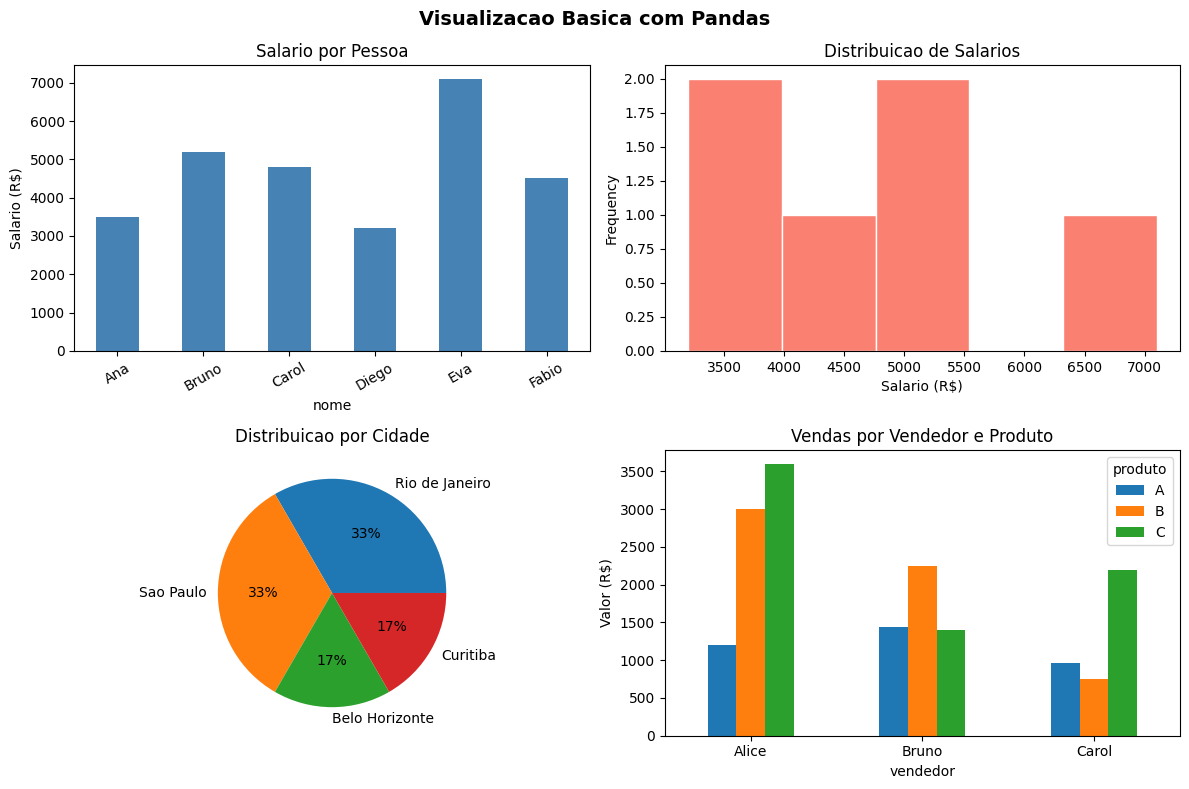

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Grafico de barras — salarios
df.set_index('nome')['salario'].plot(kind='bar', ax=axes[0,0], color='steelblue', rot=30)
axes[0,0].set_title('Salario por Pessoa')
axes[0,0].set_ylabel('Salario (R$)')

# 2. Histograma — distribuicao de salarios
df['salario'].plot(kind='hist', ax=axes[0,1], bins=5, color='salmon', edgecolor='white')
axes[0,1].set_title('Distribuicao de Salarios')
axes[0,1].set_xlabel('Salario (R$)')

# 3. Pizza — distribuicao por cidade
df['cidade'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.0f%%')
axes[1,0].set_title('Distribuicao por Cidade')
axes[1,0].set_ylabel('')

# 4. Barras agrupadas — total de vendas por produto
tabela_pivot.plot(kind='bar', ax=axes[1,1], rot=0)
axes[1,1].set_title('Vendas por Vendedor e Produto')
axes[1,1].set_ylabel('Valor (R$)')

plt.suptitle('Visualizacao Basica com Pandas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exercicio 2 — Pandas

Analise o dataset de vendas criado abaixo:

In [87]:
np.random.seed(0)

produtos = ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset']
categorias = {'Notebook': 'Computadores', 'Mouse': 'Perifericos',
              'Teclado': 'Perifericos', 'Monitor': 'Computadores', 'Headset': 'Audio'}

n = 50
prods = np.random.choice(produtos, size=n)

exercicio = pd.DataFrame({
    'data':       pd.date_range('2024-01-01', periods=n, freq='W'),
    'produto':    prods,
    'categoria':  [categorias[p] for p in prods],
    'quantidade': np.random.randint(1, 20, size=n),
    'preco_unit': np.random.choice([80, 150, 200, 900, 2500], size=n)
})
exercicio['receita'] = exercicio['quantidade'] * exercicio['preco_unit']
exercicio['mes'] = exercicio['data'].dt.month

print(f'Dataset: {exercicio.shape[0]} registros')
exercicio.head()

Dataset: 50 registros


,data,produto,categoria,quantidade,preco_unit,receita,mes
0,2024-01-07,Headset,Audio,10,80,800,1
1,2024-01-14,Notebook,Computadores,11,200,2200,1
2,2024-01-21,Monitor,Computadores,2,200,400,1
3,2024-01-28,Monitor,Computadores,2,900,1800,1
4,2024-02-04,Monitor,Computadores,8,200,1600,2


In [88]:
# Tarefa 1: Receita total e media por produto
print('=== 1. Receita por Produto ===')
por_produto = exercicio.groupby('produto')['receita'].agg(['sum', 'mean']).round(2)
por_produto.columns = ['Receita Total', 'Receita Media']
por_produto = por_produto.sort_values('Receita Total', ascending=False)
print(por_produto)
print()

=== 1. Receita por Produto ===
          Receita Total  Receita Media
produto                               
Notebook         107880        8298.46
Monitor           47560        3963.33
Mouse             33420        3342.00
Headset           21980        2442.22
Teclado            7610        1268.33



In [89]:
# Tarefa 2: Receita por categoria
print('=== 2. Receita por Categoria ===')
por_cat = exercicio.groupby('categoria')['receita'].sum().sort_values(ascending=False)
print(por_cat)
print()

=== 2. Receita por Categoria ===
categoria
Computadores    155440
Perifericos      41030
Audio            21980
Name: receita, dtype: int64



In [90]:
# Tarefa 3: Evolucao mensal
print('=== 3. Receita Mensal ===')
mensal = exercicio.groupby('mes')['receita'].sum()
print(mensal)
print(f'\nMelhor mes: {mensal.idxmax()} — R$ {mensal.max():,.2f}')
print(f'Pior mes:   {mensal.idxmin()} — R$ {mensal.min():,.2f}')

=== 3. Receita Mensal ===
mes
1      5200
2     12450
3     36900
4     40150
5      8950
6     31320
7      9200
8     27760
9      6980
10    22160
11    11580
12     5800
Name: receita, dtype: int64

Melhor mes: 4 — R$ 40,150.00
Pior mes:   1 — R$ 5,200.00


In [91]:
# Tarefa 4: Vendas de alto valor (receita acima de 5000)
print('=== 4. Vendas de Alto Valor (> R$ 5.000) ===')
alto_valor = exercicio[exercicio['receita'] > 5000].copy()
alto_valor['data_fmt'] = alto_valor['data'].dt.strftime('%d/%m/%Y')
print(alto_valor[['data_fmt', 'produto', 'quantidade', 'preco_unit', 'receita']].to_string(index=False))
print(f'\nTotal de {len(alto_valor)} vendas de alto valor')

=== 4. Vendas de Alto Valor (> R$ 5.000) ===
  data_fmt  produto  quantidade  preco_unit  receita
11/02/2024    Mouse          10         900     9000
10/03/2024 Notebook          15         900    13500
17/03/2024 Notebook          19         900    17100
14/04/2024 Notebook          13        2500    32500
02/06/2024 Notebook           4        2500    10000
30/06/2024  Monitor          15         900    13500
11/08/2024 Notebook          18         900    16200
25/08/2024    Mouse          10         900     9000
06/10/2024  Monitor          19         900    17100
17/11/2024  Headset          11         900     9900

Total de 10 vendas de alto valor


---
---

# PARTE 3 — NumPy + Pandas Juntos

Na pratica, **NumPy e Pandas trabalham juntos**.  
Pandas usa NumPy internamente, e voce pode alternar entre eles facilmente.

In [ ]:
# NUMPAY É ARRAY

In [92]:
# Extrair array NumPy de uma coluna Pandas
salarios = df['salario']
arr_salarios = salarios.to_numpy()

print('Series Pandas:', salarios.values)
print('Array NumPy:  ', arr_salarios)
print('Tipo:         ', type(arr_salarios))
print()

# Usar funcoes NumPy em colunas Pandas
print(f'Media:         R$ {np.mean(arr_salarios):,.2f}')
print(f'Desvio padrao: R$ {np.std(arr_salarios):,.2f}')
print(f'Percentil 25:  R$ {np.percentile(arr_salarios, 25):,.2f}')
print(f'Percentil 75:  R$ {np.percentile(arr_salarios, 75):,.2f}')

Series Pandas: [3500. 5200. 4800. 3200. 7100. 4500.]
Array NumPy:   [3500. 5200. 4800. 3200. 7100. 4500.]
Tipo:          <class 'numpy.ndarray'>

Media:         R$ 4,716.67
Desvio padrao: R$ 1,274.65
Percentil 25:  R$ 3,750.00
Percentil 75:  R$ 5,100.00


In [93]:
# Criar DataFrame a partir de array NumPy
np.random.seed(42)

dados_np = np.random.randint(1, 100, size=(5, 4))
print('Array NumPy:')
print(dados_np)
print()

df_from_np = pd.DataFrame(
    dados_np,
    columns=['Prova1', 'Prova2', 'Prova3', 'Prova4'],
    index=['Aluno_1', 'Aluno_2', 'Aluno_3', 'Aluno_4', 'Aluno_5']
)

print('DataFrame criado do array NumPy:')
print(df_from_np)
print()

# Calcular media de cada aluno
df_from_np['Media'] = df_from_np.mean(axis=1).round(1)
df_from_np['Situacao'] = np.where(df_from_np['Media'] >= 60, 'Aprovado', 'Reprovado')

print('Com media e situacao:')
df_from_np

Array NumPy:
[[52 93 15 72]
 [61 21 83 87]
 [75 75 88 24]
 [ 3 22 53  2]
 [88 30 38  2]]

DataFrame criado do array NumPy:
         Prova1  Prova2  Prova3  Prova4
Aluno_1      52      93      15      72
Aluno_2      61      21      83      87
Aluno_3      75      75      88      24
Aluno_4       3      22      53       2
Aluno_5      88      30      38       2

Com media e situacao:


,Prova1,Prova2,Prova3,Prova4,Media,Situacao
Aluno_1,52,93,15,72,58.0,Reprovado
Aluno_2,61,21,83,87,63.0,Aprovado
Aluno_3,75,75,88,24,65.5,Aprovado
Aluno_4,3,22,53,2,20.0,Reprovado
Aluno_5,88,30,38,2,39.5,Reprovado


---

## Resumo — Principais Funcoes

### NumPy

| Funcao | Descricao |
|--------|-----------|
| `np.array()` | Cria um array |
| `np.zeros()`, `np.ones()`, `np.full()` | Arrays com valores fixos |
| `np.arange()`, `np.linspace()` | Sequencias |
| `np.random.rand()`, `np.random.randn()`, `np.random.randint()` | Numeros aleatorios |
| `arr.shape`, `arr.ndim`, `arr.dtype` | Atributos do array |
| `arr.reshape()`, `arr.T` | Reformatar e transpor |
| `np.sum()`, `np.mean()`, `np.std()`, `np.min()`, `np.max()` | Agregacoes |
| `np.sqrt()`, `np.abs()`, `np.exp()`, `np.log()` | Matematica |
| `np.concatenate()`, `np.vstack()`, `np.hstack()` | Combinar arrays |

### Pandas

| Funcao / Metodo | Descricao |
|----------------|-----------|
| `pd.Series()`, `pd.DataFrame()` | Criar estruturas |
| `pd.read_csv()`, `df.to_csv()` | I/O de arquivos |
| `df.head()`, `df.tail()`, `df.info()`, `df.describe()` | Inspecionar |
| `df['col']`, `df[['c1','c2']]` | Selecionar colunas |
| `df.loc[]`, `df.iloc[]` | Selecionar por rotulo/posicao |
| `df[condicao]` | Filtrar linhas |
| `df.sort_values()` | Ordenar |
| `df.groupby().agg()` | Agrupar e agregar |
| `pd.merge()`, `pd.concat()` | Combinar DataFrames |
| `df.isnull()`, `df.fillna()`, `df.dropna()` | Tratar nulos |
| `df['col'].str.xxx` | Operacoes com strings |
| `df['col'].dt.xxx` | Operacoes com datas |
| `pd.pivot_table()`, `pd.crosstab()` | Tabelas cruzadas |

---

**Proximos passos:** Matplotlib, Seaborn (visualizacao) e Scikit-learn (machine learning).